СЛОЖНЫЙ МНОГОПОЛОСНЫЙ ГРАФИК УСПЕШНО СОЗДАН!

Созданы 4 различных визуализации одной функции:
1. 3D поверхность с векторами градиента
2. 2D контурный график с градиентными векторами
3. 3D диаграмма рассеяния на проволочной сетке
4. 3D проекции на все координатные плоскости

График сохранен как: 'advanced_multiplot.png' (300 DPI)
Размер фигуры: 18×14 дюймов


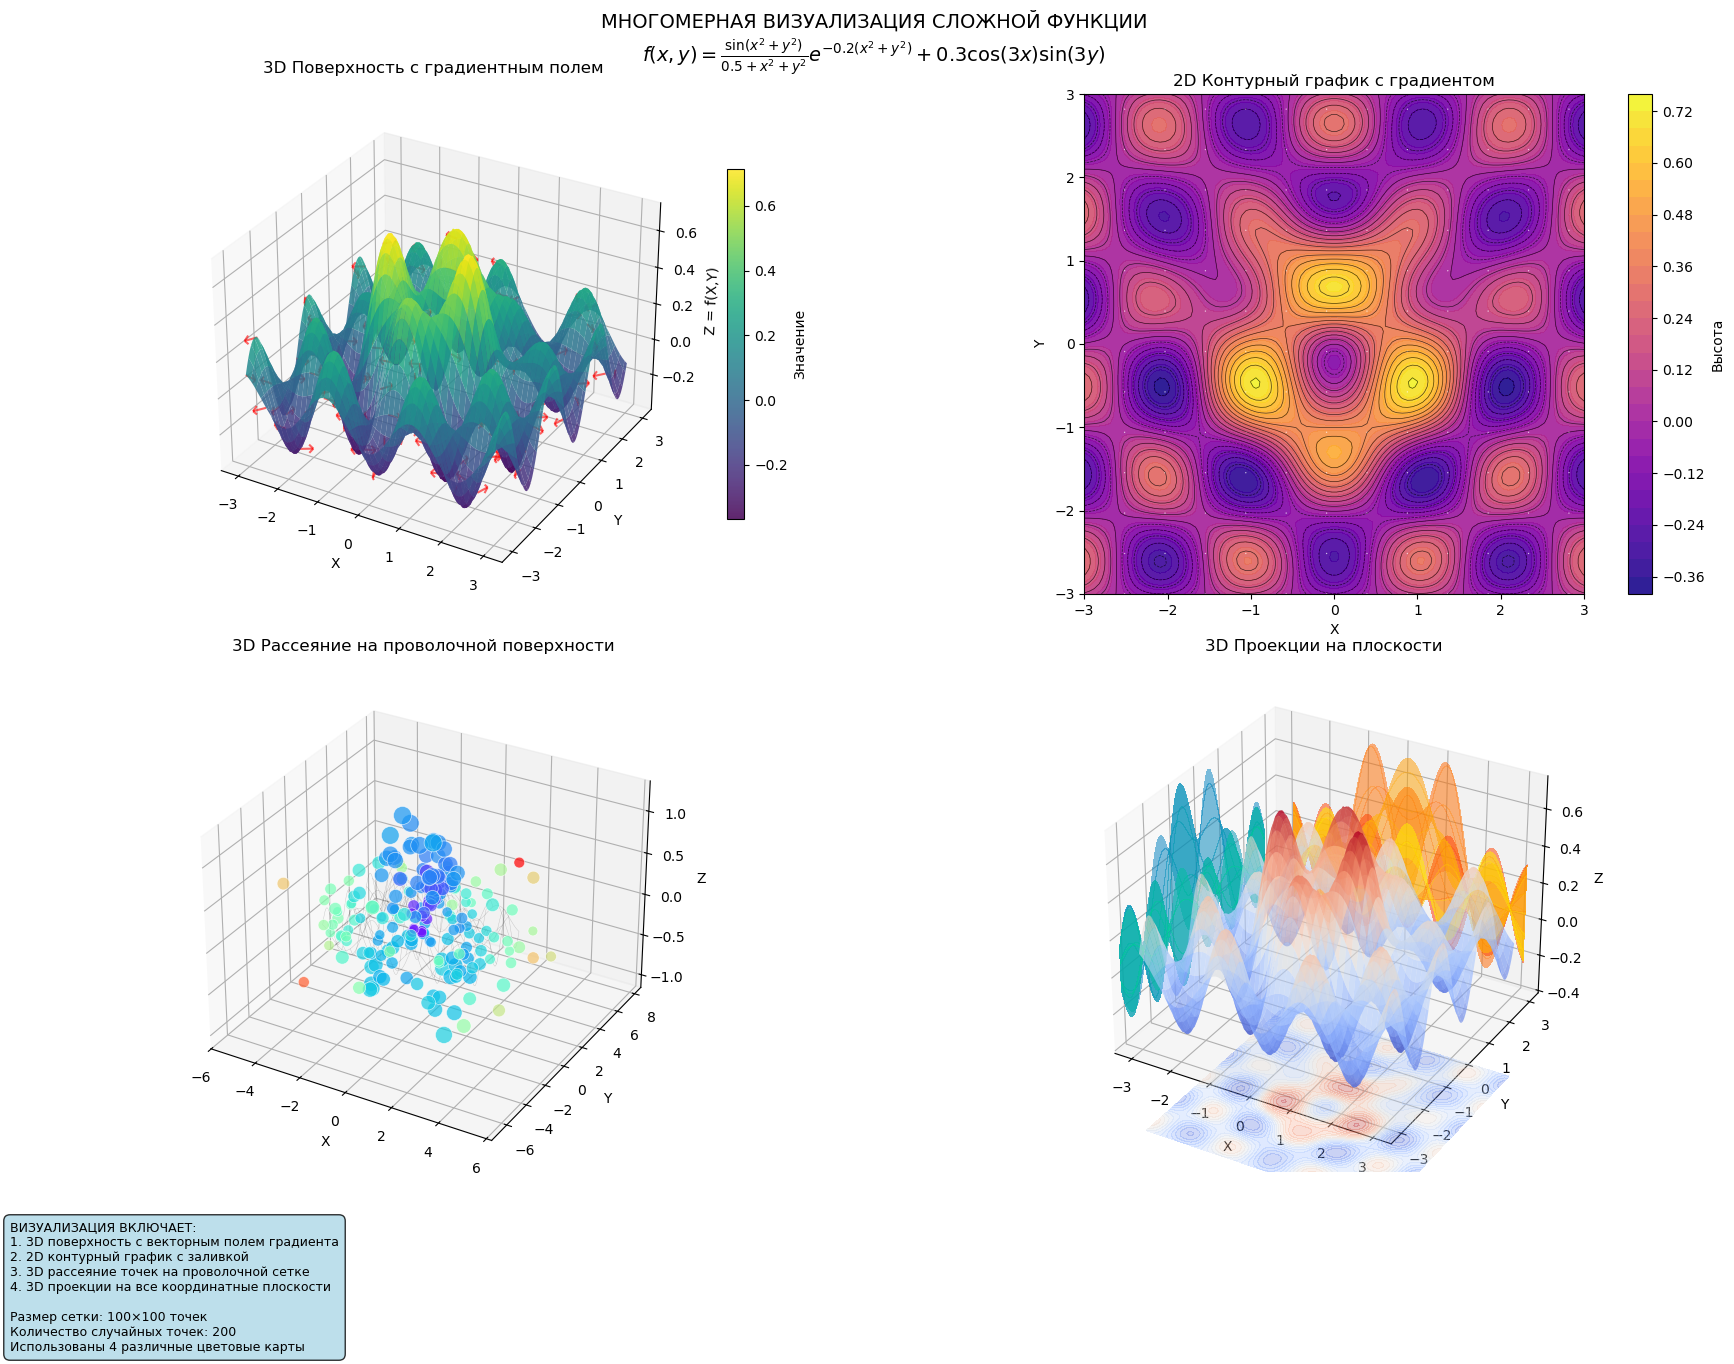

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Создаем фигуру
fig = plt.figure(figsize=(18, 14))

# ========== 1. 3D ПОВЕРХНОСТЬ С ВЕКТОРАМИ ==========
ax1 = fig.add_subplot(221, projection='3d')

# Генерация данных
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# Сложная функция с особыми точками
Z = (np.sin(X**2 + Y**2) / (0.5 + X**2 + Y**2) * 
     np.exp(-0.2*(X**2 + Y**2)) + 
     0.3*np.cos(3*X)*np.sin(3*Y))

# Вычисляем градиент ПРАВИЛЬНО
Zx, Zy = np.gradient(Z)
X_small = X[::8, ::8]
Y_small = Y[::8, ::8]
Z_small = Z[::8, ::8]
Zx_small = Zx[::8, ::8]
Zy_small = Zy[::8, ::8]

# Поверхность с освещением
surf1 = ax1.plot_surface(X, Y, Z, cmap='viridis', 
                        alpha=0.85, antialiased=True,
                        rstride=2, cstride=2,
                        linewidth=0.25)

# Векторное поле градиента
ax1.quiver(X_small, Y_small, Z_small, 
          Zx_small, Zy_small, np.zeros_like(Zx_small),
          length=0.3, color='red', alpha=0.6,
          normalize=True, arrow_length_ratio=0.3)

ax1.set_title('3D Поверхность с градиентным полем', fontsize=12, pad=15)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z = f(X,Y)')
fig.colorbar(surf1, ax=ax1, shrink=0.7, label='Значение')

# ========== 2. КОНТУРНЫЙ ГРАФИК С ЗАЛИВКОЙ ==========
ax2 = fig.add_subplot(222)

# Контурный график с заливкой
contour = ax2.contourf(X, Y, Z, levels=30, cmap='plasma', alpha=0.9)
# Линии контуров
contour_lines = ax2.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5, alpha=0.7)

# Векторы градиента на 2D графике
ax2.quiver(X_small, Y_small, Zx_small, Zy_small, 
          color='white', alpha=0.7, scale=30, width=0.003)

ax2.set_title('2D Контурный график с градиентом', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal')
fig.colorbar(contour, ax=ax2, label='Высота')

# ========== 3. 3D РАССЕЯНИЕ + ПОВЕРХНОСТЬ ==========
ax3 = fig.add_subplot(223, projection='3d')

# Генерируем случайные данные с закономерностью
np.random.seed(42)
n_points = 200
x_scatter = np.random.normal(0, 2, n_points)
y_scatter = np.random.normal(0, 2, n_points)
z_scatter = (np.sin(x_scatter**2 + y_scatter**2) * 
             np.exp(-0.1*(x_scatter**2 + y_scatter**2)) +
             0.2*np.random.randn(n_points))

# Цвет и размер точек зависят от положения и значения
colors_scatter = np.sqrt(x_scatter**2 + y_scatter**2 + z_scatter**2)
sizes = 50 + 100 * np.abs(z_scatter)

# Точки
scatter3d = ax3.scatter(x_scatter, y_scatter, z_scatter,
                       c=colors_scatter, cmap='rainbow',
                       s=sizes, alpha=0.7, edgecolors='w',
                       linewidth=0.5, depthshade=True)

# Проволочная поверхность
wire = ax3.plot_wireframe(X, Y, Z, color='black', 
                         linewidth=0.3, alpha=0.2, 
                         rstride=10, cstride=10)

ax3.set_title('3D Рассеяние на проволочной поверхности', fontsize=12, pad=15)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')

# ========== 4. ПРОЕКЦИИ НА ПЛОСКОСТИ ==========
ax4 = fig.add_subplot(224, projection='3d')

# Основная поверхность
surf4 = ax4.plot_surface(X, Y, Z, cmap='coolwarm', 
                        alpha=0.6, rstride=2, cstride=2)

# Проекция на плоскость XY
ax4.contourf(X, Y, Z, zdir='z', offset=Z.min()-0.5, 
            cmap='coolwarm', alpha=0.3, levels=20)

# Проекция на плоскость XZ
ax4.contourf(X, Y, Z, zdir='y', offset=Y.max()+0.5, 
            cmap='autumn', alpha=0.3, levels=20)

# Проекция на плоскость YZ
ax4.contourf(X, Y, Z, zdir='x', offset=X.min()-0.5, 
            cmap='winter', alpha=0.3, levels=20)

ax4.set_title('3D Проекции на плоскости', fontsize=12, pad=15)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_box_aspect([1,1,0.8])

# ========== ОБЩИЕ НАСТРОЙКИ ==========
plt.suptitle('МНОГОМЕРНАЯ ВИЗУАЛИЗАЦИЯ СЛОЖНОЙ ФУНКЦИИ\n' +
             r'$f(x,y) = \frac{\sin(x^2+y^2)}{0.5+x^2+y^2}e^{-0.2(x^2+y^2)} + 0.3\cos(3x)\sin(3y)$',
             fontsize=14, y=0.98)

# Добавляем информационную панель
info_text = (
    "ВИЗУАЛИЗАЦИЯ ВКЛЮЧАЕТ:\n"
    "1. 3D поверхность с векторным полем градиента\n"
    "2. 2D контурный график с заливкой\n"
    "3. 3D рассеяние точек на проволочной сетке\n"
    "4. 3D проекции на все координатные плоскости\n\n"
    f"Размер сетки: {X.shape[0]}×{X.shape[1]} точек\n"
    f"Количество случайных точек: {n_points}\n"
    "Использованы 4 различные цветовые карты"
)

fig.text(0.02, 0.02, info_text, fontsize=9,
         verticalalignment='bottom',
         bbox=dict(boxstyle="round,pad=0.5",
                   facecolor="lightblue",
                   alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)

# Сохраняем
plt.savefig('advanced_multiplot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

print("="*70)
print("СЛОЖНЫЙ МНОГОПОЛОСНЫЙ ГРАФИК УСПЕШНО СОЗДАН!")
print("="*70)
print("\nСозданы 4 различных визуализации одной функции:")
print("1. 3D поверхность с векторами градиента")
print("2. 2D контурный график с градиентными векторами")
print("3. 3D диаграмма рассеяния на проволочной сетке")
print("4. 3D проекции на все координатные плоскости")
print("\nГрафик сохранен как: 'advanced_multiplot.png' (300 DPI)")
print("Размер фигуры: 18×14 дюймов")

plt.show()

In [ ]:
import math
pi = math.pi
phi = (1 + math.sqrt(5)) / 2
a = math.e**(1j*pi) + 2*phi
print(a)

NameError: name 'j' is not defined